# Quantum Tilted Loss in QAOA and HEA for MaxCut

This notebook explores the performance of the **Quantum Tilted Loss Function** in solving the MaxCut problem using the **Quantum Approximate Optimization Algorithm (QAOA)** and a **Hardware Efficient Ansatz (HEA)**.

### 1. Mathematical Background
The standard loss function in VQA is the expectation value of the Hamiltonian:
$$\mathcal{L}_{std}(\theta) = \bra{\psi(\theta)} H \ket{\psi(\theta)}$$

The **Quantum Tilted Loss Function** is defined as:
$$\mathcal{L}_\gamma(H,\rho(\theta)) := - \frac{1}{\gamma} \log \text{tr} \left( e^{- \gamma H} \rho(\theta) \right)$$
where $\gamma$ is a real parameter. As $\gamma \to 0$, it recovers the standard expectation value. For $\gamma > 0$, it penalizes high-energy (sub-optimal) states more heavily, potentially accelerating convergence to the ground state.

### 2. Goal
1. Compare Standard Loss vs Tilted Loss for MaxCut with QAOA.
2. Test Tilted Loss with Hardware Efficient Ansatz.
3. Compare the algorithm performance with different fixed values of $\gamma$ (0.1, 5, 10, 20, 100).
4. Investigate the effect of tuning $\gamma$ using different schedules (Linear, Sigmoid, Exponential, Logarithmic).

In [1]:
%%capture

# Comment this out if you don't want to install pennylane from this notebook
!pip install pennylane

# Comment this out if you don't want to install matplotlib from this notebook
!pip install matplotlib

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time
import math
from dataclasses import dataclass

from IPython.display import display
import pennylane as qml
from pennylane import numpy as qnp

import networkx as nx

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)

In [3]:
@dataclass(frozen=True)
class ObjectiveSpec:
    name: str
    kind: str
    alpha: float | None = None
    gamma: float | None = None
    gamma_start: float | None = None
    gamma_end: float | None = None
    schedule: str | None = None
    color: str = "C0"


MAIN_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("QTL gamma=2.0", "qtl", gamma=2.0, color="#2ca02c"),
    ObjectiveSpec("QTL gamma=5.0", "qtl", gamma=5.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=5,
        schedule="linear",
        color="#9467bd",
    ),
]


SCHEDULE_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("QTL gamma=5.0", "qtl", gamma=5.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=5,
        schedule="linear",
        color="#9467bd",
    ),
    ObjectiveSpec(
        "QTL schedule sigmoid",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=5,
        schedule="sigmoid",
        color="#e377c2",
    ),
    ObjectiveSpec(
        "QTL reverse linear",
        "qtl_schedule",
        gamma_start=5,
        gamma_end=0,
        schedule="linear",
        color="#7f7f7f",
    ),
]

FIXED_GAMMA_GRID = [0.5, 5, 20, 100, 200]
GAMMA_GRID_OBJECTIVES = [
    ObjectiveSpec(f"QTL gamma={gamma}", "qtl", gamma=gamma, color=plt.cm.viridis(i / (len(FIXED_GAMMA_GRID) - 1)))
    for i, gamma in enumerate(FIXED_GAMMA_GRID)
] + [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=5,
        schedule="linear",
        color="#9467bd",
    ),
]

CURVE_OBJECTIVES = ["Expectation", "QTL gamma=2.0", "QTL gamma=5.0", "QTL schedule linear"]
HARD_OBJECTIVES = ["Expectation", "QTL gamma=5.0", "QTL schedule linear"]
BUDGET_OBJECTIVES = ["Expectation", "QTL gamma=5.0", "QTL schedule linear"]

ALL_OBJECTIVES = {
    obj.name: obj
    for obj in MAIN_OBJECTIVES + SCHEDULE_OBJECTIVES + GAMMA_GRID_OBJECTIVES
}
OBJECTIVE_COLORS = {name: obj.color for name, obj in ALL_OBJECTIVES.items()}

FAST_CONFIG = {
    # "graph_families": ["regular3"],
    "graph_families": ["erdos_renyi"],
    "sizes": [8],
    # "sizes": [8, 10, 12],
    # "depths": [1, 2, 3],
    "depths": [2],
    # "depths": [3],
    "seeds": [0],
    # "seeds": [0, 1, 2],
    "lr": 0.18,
    "lr_decay_power": 0.55,
    "lr_decay_offset": 6.0,
    "beta_mom": 0.7,
    "gamma_lr_penalty": 0.02,
    "grad_clip": 2.5,
    "steps": 150,
    "shots": 1024,
    "gradient_probes": 4,
    "target_ratio": 0.99,
    "curve_n": 8,
    "summary_n": 8,
    "summary_p": 2,
    "budget_n": 8,
    "budget_p": 2,
    "budget_seeds": [0, 1, 2],
    "budget_shots_grid": [64, 128, 256, 512],
    "budget_total_shots": 15360,
    "gamma_grid_n": 8,
    "gamma_grid_p": 2,
    "schedule_n": 8,
    "schedule_p": 2,
}

FULL_CONFIG = {
    **FAST_CONFIG,
    "graph_families": ["erdos_renyi"],
    # "graph_families": ["regular3", "erdos_renyi"],
    "seeds": list(range(8)),
    "steps": 150,
    "shots": 1024,
    "gradient_probes": 8,
    "budget_seeds": list(range(8)),
}

RUN_CONFIG = FAST_CONFIG
print("Running config:", RUN_CONFIG)

EXACT_SMALL_SCALE_CONFIG = {
    **FAST_CONFIG,
    "sizes": [8],
    "depths": [2],
    "seeds": [0],
    "steps": 150,
    "shots": 256,
}


Running config: {'graph_families': ['erdos_renyi'], 'sizes': [8], 'depths': [2], 'seeds': [0], 'lr': 0.18, 'lr_decay_power': 0.55, 'lr_decay_offset': 6.0, 'beta_mom': 0.7, 'gamma_lr_penalty': 0.02, 'grad_clip': 2.5, 'steps': 150, 'shots': 1024, 'gradient_probes': 4, 'target_ratio': 0.99, 'curve_n': 8, 'summary_n': 8, 'summary_p': 2, 'budget_n': 8, 'budget_p': 2, 'budget_seeds': [0, 1, 2], 'budget_shots_grid': [64, 128, 256, 512], 'budget_total_shots': 15360, 'gamma_grid_n': 8, 'gamma_grid_p': 2, 'schedule_n': 8, 'schedule_p': 2}


## Task 1: QAOA Comparison (Standard vs CVaR vs Tilted)

We calculate the exact maximum cuts of the graphs using brute force sampling search, which is denoted by $c_{max}$. Then we use QAOA algorithm to solve the maxcut problem and return us with the final bit string that corresponds to a cut $c_{obtained}$. Then we evaluate the approximation ratio of this obtained cut compared to the exact maximum cut, and plot the figure.

In [4]:
# Code to generate the graph
def make_graph(n, family, seed):
    if family == "regular3":
        graph = nx.random_regular_graph(3, n, seed=seed)
    elif family == "erdos_renyi":
        p = min(0.45, 3.0 / (n - 1))
        graph = nx.gnp_random_graph(n, p, seed=seed)
        while not nx.is_connected(graph):
            seed += 1
            graph = nx.gnp_random_graph(n, p, seed=seed)
    else:
        raise ValueError(f"Unknown graph family: {family}")
    return graph


def basis_states(n):
    return np.array([list(map(int, f"{i:0{n}b}")) for i in range(2**n)], dtype=int)


def cut_values_from_samples(samples, edges):
    samples = np.asarray(samples, dtype=int)
    cuts = np.zeros(samples.shape[0], dtype=int)
    for u, v in edges:
        cuts += (samples[:, u] != samples[:, v]).astype(int)
    return cuts


def exact_cut_data(n, edges):
    basis = basis_states(n)
    cuts = cut_values_from_samples(basis, edges)
    return basis, cuts.astype(float), float(cuts.max())

[(0, 1), (0, 4), (1, 3), (1, 4), (2, 3), (2, 6), (3, 5), (3, 6), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
[ 0.  3.  5.  6.  3.  4.  6.  5.  4.  5.  7.  6.  7.  6.  8.  5.  4.  7.
  7.  8.  5.  6.  6.  5.  8.  9.  9.  8.  9.  8.  8.  5.  2.  5.  5.  6.
  5.  6.  6.  5.  6.  7.  7.  6.  9.  8.  8.  5.  4.  7.  5.  6.  5.  6.
  4.  3.  8.  9.  7.  6.  9.  8.  6.  3.  3.  6.  8.  9.  6.  7.  9.  8.
  5.  6.  8.  7.  8.  7.  9.  6.  5.  8.  8.  9.  6.  7.  7.  6.  7.  8.
  8.  7.  8.  7.  7.  4.  5.  8.  8.  9.  8.  9.  9.  8.  7.  8.  8.  7.
 10.  9.  9.  6.  5.  8.  6.  7.  6.  7.  5.  4.  7.  8.  6.  5.  8.  7.
  5.  2.  2.  5.  7.  8.  5.  6.  8.  7.  4.  5.  7.  6.  7.  6.  8.  5.
  6.  9.  9. 10.  7.  8.  8.  7.  8.  9.  9.  8.  9.  8.  8.  5.  4.  7.
  7.  8.  7.  8.  8.  7.  6.  7.  7.  6.  9.  8.  8.  5.  6.  9.  7.  8.
  7.  8.  6.  5.  8.  9.  7.  6.  9.  8.  6. 

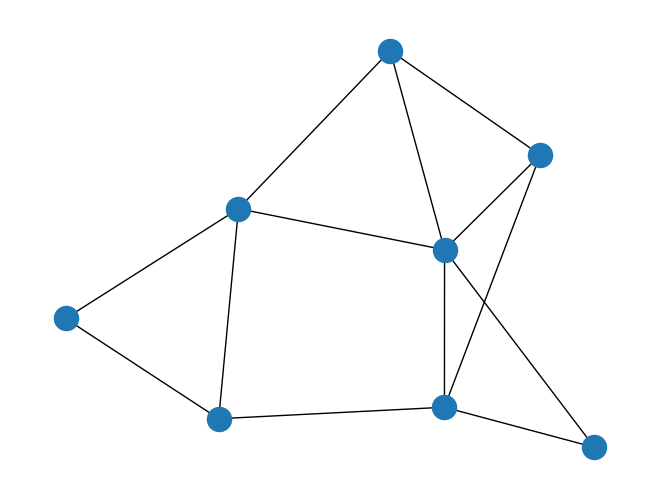

In [5]:
n = 8
family = 'erdos_renyi'
# Set random seed for reproducibility
# seed = np.random.seed(42)
G = make_graph(n, family, 1)
nx.draw(G)

edges = sorted(G.edges())
print(edges)

a,b,c = exact_cut_data(n, edges)
print(a)
print(b)
print(c)

Define the Hamiltonian

In [6]:
# # Define a small graph for MaxCut (4-node ring)
# nodes = 4
# edges = [(0, 1), (1, 2), (2, 3), (3, 0)]


# Hamiltonian: H = sum 0.5 * (Zi * Zj - 1) for (i,j) in edges
# Minimizing this minimizes edges with same spin, thus maximizing the cut.
coeffs = [0.5] * len(edges) + [-0.5] * len(edges)
obs = [qml.PauliZ(i) @ qml.PauliZ(j) for i, j in edges] + [qml.Identity(i) for i in range(len(edges))]
H = qml.Hamiltonian(coeffs, obs)

print(f'Hamiltonian for {n}-node MaxCut:\n', H)

Hamiltonian for 8-node MaxCut:
 0.5 * (Z(0) @ Z(1)) + 0.5 * (Z(0) @ Z(4)) + 0.5 * (Z(1) @ Z(3)) + 0.5 * (Z(1) @ Z(4)) + 0.5 * (Z(2) @ Z(3)) + 0.5 * (Z(2) @ Z(6)) + 0.5 * (Z(3) @ Z(5)) + 0.5 * (Z(3) @ Z(6)) + 0.5 * (Z(4) @ Z(6)) + 0.5 * (Z(4) @ Z(7)) + 0.5 * (Z(5) @ Z(6)) + 0.5 * (Z(5) @ Z(7)) + 0.5 * (Z(6) @ Z(7)) + -0.5 * I(0) + -0.5 * I(1) + -0.5 * I(2) + -0.5 * I(3) + -0.5 * I(4) + -0.5 * I(5) + -0.5 * I(6) + -0.5 * I(7) + -0.5 * I(8) + -0.5 * I(9) + -0.5 * I(10) + -0.5 * I(11) + -0.5 * I(12)


Define the loss functions.

In [7]:
def qtl_loss_from_distribution(probs, losses, gamma):
    probs = qml.math.asarray(probs)
    losses = qml.math.asarray(losses)
    if gamma is None or abs(gamma) < 1e-12:
        return qml.math.dot(probs, losses)
    loss_min = qml.math.min(losses)
    shifted = losses - loss_min
    weighted = qml.math.sum(probs * qml.math.exp(-gamma * shifted))
    return loss_min - qml.math.log(weighted) / gamma


def _sigmoid_frac(frac):
    base = 1.0 / (1.0 + np.exp(-12.0 * (frac - 0.5)))
    low = 1.0 / (1.0 + np.exp(6.0))
    high = 1.0 / (1.0 + np.exp(-6.0))
    return float((base - low) / (high - low))


def scheduled_gamma(spec, step, total_steps):
    if spec.kind != "qtl_schedule":
        return spec.gamma
    if total_steps <= 1:
        return float(spec.gamma_end)
    frac = step / (total_steps - 1)
    if spec.schedule == "linear":
        schedule_frac = frac
    elif spec.schedule == "sigmoid":
        schedule_frac = _sigmoid_frac(frac)
    elif spec.schedule == "piecewise":
        if frac < 0.5:
            schedule_frac = 0.2 * frac / 0.5
        else:
            schedule_frac = 0.2 + 0.8 * (frac - 0.5) / 0.5
    else:
        raise ValueError(f"Unknown schedule: {spec.schedule}")
    return float(spec.gamma_start + schedule_frac * (spec.gamma_end - spec.gamma_start))


def objective_loss_from_distribution(probs, cuts, c_max: float, spec: ObjectiveSpec, step: int, total_steps: int):
    losses = c_max - qml.math.asarray(cuts)
    if spec.kind == "expectation":
        return qml.math.dot(probs, losses)
    gamma = scheduled_gamma(spec, step, total_steps)
    return qtl_loss_from_distribution(probs, losses, gamma)


Define the QAOA circuit and optimizer.

In [8]:
def make_qaoa_prob_qnode(
    n: int,
    edges: list[tuple[int, int]],
    *,
    shots: int | None,
    device_seed: int,
):
    dev = qml.device("default.qubit", wires=n, seed=int(device_seed))

    @qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
    def base_circuit(params):
        p = len(params) // 2
        gammas = params[:p]
        betas = params[p:]
        for wire in range(n):
            qml.Hadamard(wires=wire)
        for gamma, beta in zip(gammas, betas):
            for u, v in edges:
                qml.IsingZZ(2.0 * gamma, wires=[u, v])
            for wire in range(n):
                qml.RX(2.0 * beta, wires=wire)
        return qml.probs(wires=range(n))

    if shots is None:
        return base_circuit
    return qml.set_shots(base_circuit, shots=shots)


def summarize_probs(probs: np.ndarray, cuts: np.ndarray, c_max: float) -> dict[str, float]:
    optimal_mask = cuts == c_max
    support_mask = probs > 1e-12
    best_cut = float(np.max(cuts[support_mask])) if np.any(support_mask) else float(np.max(cuts))
    return {
        "mean_cut": float(np.dot(probs, cuts)),
        "mean_ratio": float(np.dot(probs, cuts) / c_max),
        "best_cut": best_cut,
        "best_ratio": float(best_cut / c_max),
        "optimal_mass": float(probs[optimal_mask].sum()),
    }


def optimize_parameter(
    circuit,
    cuts: np.ndarray,
    c_max: float,
    init_params: np.ndarray,
    spec: ObjectiveSpec,
    config: dict,
    *,
    exact: bool,
):
    params = qnp.array(init_params, requires_grad=True)
    momentum = np.zeros_like(np.asarray(init_params, dtype=float))
    best_cut_so_far = -np.inf
    evals_per_step = 2 * len(init_params) + 2
    history = []

    for step in range(config["steps"]):
        def loss_fn(theta):
            wrapped = qnp.mod(theta, 2 * np.pi)
            probs = circuit(wrapped)
            return objective_loss_from_distribution(probs, cuts, c_max, spec, step, config["steps"])

        grad = np.asarray(qml.grad(loss_fn)(params), dtype=float)
        grad_norm = float(np.linalg.norm(grad))
        if grad_norm > config["grad_clip"]:
            grad = grad * (config["grad_clip"] / grad_norm)

        momentum = config["beta_mom"] * momentum + (1.0 - config["beta_mom"]) * grad
        step_lr = config["lr"] / ((step + 1 + config["lr_decay_offset"]) ** config["lr_decay_power"])
        gamma_now = scheduled_gamma(spec, step, config["steps"])
        if gamma_now is not None and config["gamma_lr_penalty"] > 0.0:
            step_lr = step_lr / (1.0 + config["gamma_lr_penalty"] * abs(gamma_now))

        updated = np.mod(np.asarray(params, dtype=float) - step_lr * momentum, 2 * np.pi)
        params = qnp.array(updated, requires_grad=True)

        probs = np.asarray(circuit(params), dtype=float)
        metrics = summarize_probs(probs, cuts, c_max)
        best_cut_so_far = max(best_cut_so_far, metrics["best_cut"])
        history.append(
            {
                "iteration": step + 1,
                "loss": float(loss_fn(params)),
                "mean_cut": metrics["mean_cut"],
                "mean_ratio": metrics["mean_ratio"],
                "best_ratio_step": metrics["best_ratio"],
                "best_ratio_so_far": float(best_cut_so_far / c_max),
                "best_cut_so_far": int(best_cut_so_far),
                "optimal_mass": metrics["optimal_mass"],
                "gamma": np.nan if gamma_now is None else float(gamma_now),
                "lr": float(step_lr),
                "grad_norm": float(np.linalg.norm(grad)),
                "circuit_evals": int((step + 1) * evals_per_step),
                "shots_used": np.nan if exact else int((step + 1) * evals_per_step * config["shots"]),
            }
        )

    return params, pd.DataFrame(history)


def run_single_setting(
    graph_family: str,
    n: int,
    p: int,
    seed: int,
    spec: ObjectiveSpec,
    config: dict,
    *,
    exact: bool,
):
    graph = make_graph(n, graph_family, seed)
    edges = sorted(graph.edges())
    _, cuts, c_max = exact_cut_data(n, edges)

    init_rng = np.random.default_rng(10_000 * n + 100 * p + seed)
    init_params = init_rng.uniform(0.0, np.pi, size=2 * p)
    circuit = make_qaoa_prob_qnode(
        n,
        edges,
        shots=None if exact else config["shots"],
        device_seed=2024 + 100 * seed + 10 * p + n,
    )

    _, history = optimize_parameter(circuit, cuts, c_max, init_params, spec, config, exact=exact)
    history["graph_family"] = graph_family
    history["n"] = n
    history["p"] = p
    history["seed"] = seed
    history["objective"] = spec.name
    history["mode"] = "exact" if exact else "sampled"

    final_row = history.iloc[-1]
    target_hits = history.loc[history["best_ratio_so_far"] >= config["target_ratio"], "iteration"]
    final_summary = {
        "graph_family": graph_family,
        "n": n,
        "p": p,
        "seed": seed,
        "objective": spec.name,
        "mode": "exact" if exact else "sampled",
        "final_mean_ratio": float(final_row["mean_ratio"]),
        "final_best_ratio": float(final_row["best_ratio_so_far"]),
        "best_observed_cut": int(final_row["best_cut_so_far"]),
        "success_target": float(final_row["best_ratio_so_far"] >= config["target_ratio"]),
        "steps_to_target": int(target_hits.iloc[0]) if len(target_hits) else np.nan,
        "loss_volatility": float(history["loss"].std()),
        "final_optimal_mass": float(final_row["optimal_mass"]),
        "shots": np.nan if exact else int(config["shots"]),
        "total_shots": np.nan if exact else float(final_row["shots_used"]),
        "circuit_evals": int(final_row["circuit_evals"]),
        "final_loss": float(final_row["loss"]),
    }
    return history, final_summary


def run_benchmark(config: dict, objectives: list[ObjectiveSpec], *, exact: bool):
    curve_rows = []
    final_rows = []

    for graph_family in config["graph_families"]:
        for n in config["sizes"]:
            for p in config["depths"]:
                for seed in config["seeds"]:
                    print(
                        f"Benchmark ({'exact' if exact else 'sampled'}): family={graph_family}, n={n}, p={p}, seed={seed}"
                    )
                    for spec in objectives:
                        history, final_summary = run_single_setting(
                            graph_family,
                            n,
                            p,
                            seed,
                            spec,
                            config,
                            exact=exact,
                        )
                        curve_rows.append(history)
                        final_rows.append(final_summary)

    return pd.concat(curve_rows, ignore_index=True), pd.DataFrame(final_rows)


def summarize_final_results(final_df: pd.DataFrame, value_col: str = "final_mean_ratio") -> pd.DataFrame:
    return (
        final_df.groupby(["mode", "objective"])[value_col]
        .mean()
        .unstack(0)
        .sort_values("sampled", ascending=False)
    )


def run_exact_small_scale_comparison(objectives: list[ObjectiveSpec]) -> pd.DataFrame:
    _, sampled_final = run_paramshift_benchmark(EXACT_SMALL_SCALE_CONFIG, objectives, exact=False)
    _, exact_final = run_paramshift_benchmark(EXACT_SMALL_SCALE_CONFIG, objectives, exact=True)

    comparison = (
        sampled_final.groupby("objective")[["final_mean_ratio", "final_best_ratio", "success_target", "steps_to_target", "final_optimal_mass"]]
        .mean()
        .rename(
            columns={
                "final_mean_ratio": "sampled_mean_ratio",
                "final_best_ratio": "sampled_best_ratio",
                "success_target": "sampled_success_target",
                "steps_to_target": "sampled_steps_to_target",
                "final_optimal_mass": "sampled_optimal_mass",
            }
        )
        .join(
            exact_final.groupby("objective")[["final_mean_ratio", "final_optimal_mass"]]
            .mean()
            .rename(
                columns={
                    "final_mean_ratio": "exact_mean_ratio",
                    "final_optimal_mass": "exact_optimal_mass",
                }
            )
        )
    )
    comparison["mean_ratio_gap_exact_minus_sampled"] = comparison["exact_mean_ratio"] - comparison["sampled_mean_ratio"]
    comparison["optimal_mass_gap_exact_minus_sampled"] = comparison["exact_optimal_mass"] - comparison["sampled_optimal_mass"]
    return comparison.sort_values(["sampled_best_ratio", "sampled_mean_ratio"], ascending=False)



def exact_descent_trace(objective, init_params, steps, lr=0.18):
    params = np.asarray(init_params, dtype=float).copy()
    rows = []
    for step in range(steps):
        value, metrics = objective(params, step)
        rows.append(
            {
                "iteration": step + 1,
                "param_gamma": float(params[0]),
                "param_beta": float(params[1]),
                "objective": float(value),
                "mean_ratio": float(metrics["mean_ratio"]),
                "optimal_mass": float(metrics["optimal_mass"]),
                "gamma": metrics["gamma"],
            }
        )
        grad = finite_difference_grad(objective, params, step)
        params = np.mod(params - lr * grad, 2 * np.pi)
    return pd.DataFrame(rows)


def build_landscape(objective, gamma_grid, beta_grid, step):
    values = np.zeros((len(beta_grid), len(gamma_grid)))
    for i, beta in enumerate(beta_grid):
        for j, gamma in enumerate(gamma_grid):
            val, _ = objective(np.array([gamma, beta]), step)
            values[i, j] = val
    return values


def find_landscape_demo():
    fixed_spec = ALL_OBJECTIVES["QTL gamma=20.0"]
    sched_spec = ALL_OBJECTIVES["QTL schedule linear"]
    reverse_spec = ALL_OBJECTIVES["QTL reverse linear"]
    best = None
    best_gap = -np.inf

    for graph_seed in range(8):
        graph = make_graph(6, "regular3", graph_seed)
        edges = sorted(graph.edges())
        fixed_obj, _, _ = make_exact_objective(6, edges, fixed_spec, total_steps=24)
        sched_obj, _, _ = make_exact_objective(6, edges, sched_spec, total_steps=24)
        reverse_obj, _, _ = make_exact_objective(6, edges, reverse_spec, total_steps=24)
        for init_seed in range(20):
            rng = np.random.default_rng(50_000 + 100 * graph_seed + init_seed)
            init_params = rng.uniform(0.0, np.pi, size=2)
            fixed_trace = exact_descent_trace(fixed_obj, init_params, steps=24, lr=0.16)
            sched_trace = exact_descent_trace(sched_obj, init_params, steps=24, lr=0.16)
            reverse_trace = exact_descent_trace(reverse_obj, init_params, steps=24, lr=0.16)
            gap = sched_trace["optimal_mass"].iloc[-1] - fixed_trace["optimal_mass"].iloc[-1]
            if gap > best_gap:
                best_gap = gap
                best = {
                    "graph_seed": graph_seed,
                    "init_seed": init_seed,
                    "graph": graph,
                    "edges": edges,
                    "init_params": init_params,
                    "fixed_trace": fixed_trace,
                    "sched_trace": sched_trace,
                    "reverse_trace": reverse_trace,
                }
            if gap > 0.08:
                return best
    return best
    


## Run the benchmarks

The notebook keeps the main benchmark compact, then adds three targeted ablations to justify scheduling:

- **Main benchmark**: expectation / fixed-QTL / scheduled-QTL over `n = 8, 10, 12` and `p = 1, 2, 3`.
- **Fixed-gamma grid**: one representative setting to test whether any constant gamma dominates.
- **Schedule ablation**: low-to-high, high-to-low, and sigmoid schedules on a harder low-depth setting.
- **Landscape demo**: a small exact `p = 1` case to visualize how changing gamma changes the objective geometry.

The default `FAST_CONFIG` is meant for iteration. Switch to `FULL_CONFIG` if you want paper-ready averages.


- Benchmark 1: standard loss function vs tilted loss function for different fixed gammas.

In [9]:
curve_df, final_df = run_benchmark(RUN_CONFIG, MAIN_OBJECTIVES, exact=False)
# budget_df = run_budget_tradeoff(RUN_CONFIG, BUDGET_OBJECTIVES)

fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]


Benchmark (sampled): family=erdos_renyi, n=8, p=2, seed=0


In [10]:
curve_df

,iteration,loss,mean_cut,mean_ratio,best_ratio_step,best_ratio_so_far,best_cut_so_far,optimal_mass,gamma,lr,grad_norm,circuit_evals,shots_used,graph_family,n,p,seed,objective,mode
0,1,4.748047,2.275391,0.325056,1.0,1.0,7,0.000977,NaN,0.061726,2.500000,10,10240,erdos_renyi,8,2,0,Expectation,sampled
1,2,4.228516,2.715820,0.387974,1.0,1.0,7,0.000977,NaN,0.057355,2.500000,20,20480,erdos_renyi,8,2,0,Expectation,sampled
2,3,3.928711,3.169922,0.452846,1.0,1.0,7,0.000977,NaN,0.053758,2.500000,30,30720,erdos_renyi,8,2,0,Expectation,sampled
3,4,3.382812,3.515625,0.502232,1.0,1.0,7,0.002930,NaN,0.050731,2.500000,40,40960,erdos_renyi,8,2,0,Expectation,sampled
4,5,3.124023,3.879883,0.554269,1.0,1.0,7,0.014648,NaN,0.048140,2.500000,50,51200,erdos_renyi,8,2,0,Expectation,sampled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,146,0.306854,5.476562,0.782366,1.0,1.0,7,0.195312,4.865772,0.010350,0.129574,1460,1495040,erdos_renyi,8,2,0,QTL schedule linear,sampled
596,147,0.310035,5.532227,0.790318,1.0,1.0,7,0.220703,4.899329,0.010306,0.136540,1470,1505280,erdos_renyi,8,2,0,QTL schedule linear,sampled
597,148,0.307307,5.571289,0.795898,1.0,1.0,7,0.235352,4.932886,0.010263,0.065313,1480,1515520,erdos_renyi,8,2,0,QTL schedule linear,sampled
598,149,0.301783,5.593750,0.799107,1.0,1.0,7,0.233398,4.966443,0.010220,0.059644,1490,1525760,erdos_renyi,8,2,0,QTL schedule linear,sampled


In [11]:
finite_summary = (
    final_df.groupby("objective")[["final_mean_ratio", "final_best_ratio", "final_optimal_mass", "success_target", "steps_to_target", "final_loss"]]
    .mean()
    .sort_values(["final_best_ratio", "final_mean_ratio"], ascending=False)
)
display(finite_summary.round(4))

,final_mean_ratio,final_best_ratio,final_optimal_mass,success_target,steps_to_target,final_loss
objective,,,,,,
QTL gamma=2.0,0.7959,1.0,0.2324,1.0,1.0,0.6012
QTL schedule linear,0.7921,1.0,0.2324,1.0,1.0,0.2777
QTL gamma=5.0,0.7903,1.0,0.2334,1.0,1.0,0.2754
Expectation,0.6240,1.0,0.0273,1.0,1.0,2.6553


In [12]:
# Save to CSV
curve_df.to_csv('curve_df.csv')

In [13]:
fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]

In [14]:
def jump_points(x, y):
    x_new = [(x[i] + x[i + 1] + x[i + 2]) / 3 for i in range(0, len(x), 3)]
    y_new = [(y[i] + y[i + 1] + y[i + 2]) / 3 for i in range(0, len(y), 3)]
    return x_new, y_new

# def plot_mean_with_band(ax, df, x_col, y_col, label, color):
#     agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
#     # x, y = jump_points(agg[x_col], agg["mean"])
#     ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    # ax.plot(x, y, label=label, color=color, linewidth=2)
    # std = agg["std"].fillna(0.0)
    # ax.fill_between(
    #     agg[x_col],
    #     agg["mean"] - std,
    #     agg["mean"] + std,
    #     color=color,
    #     alpha=0.15,
    # )
def plot_mean_with_band(ax, df, x_col, y_col, label, color):
    agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    # x, y = jump_points(agg[x_col], agg["mean"])
    # ax.plot(x, y, label=label, color=color, linewidth=2)
    ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    ax.scatter([agg[x_col].iloc[-1]], [agg["mean"].iloc[-1]], color=color, s=28, zorder=3)
    return agg


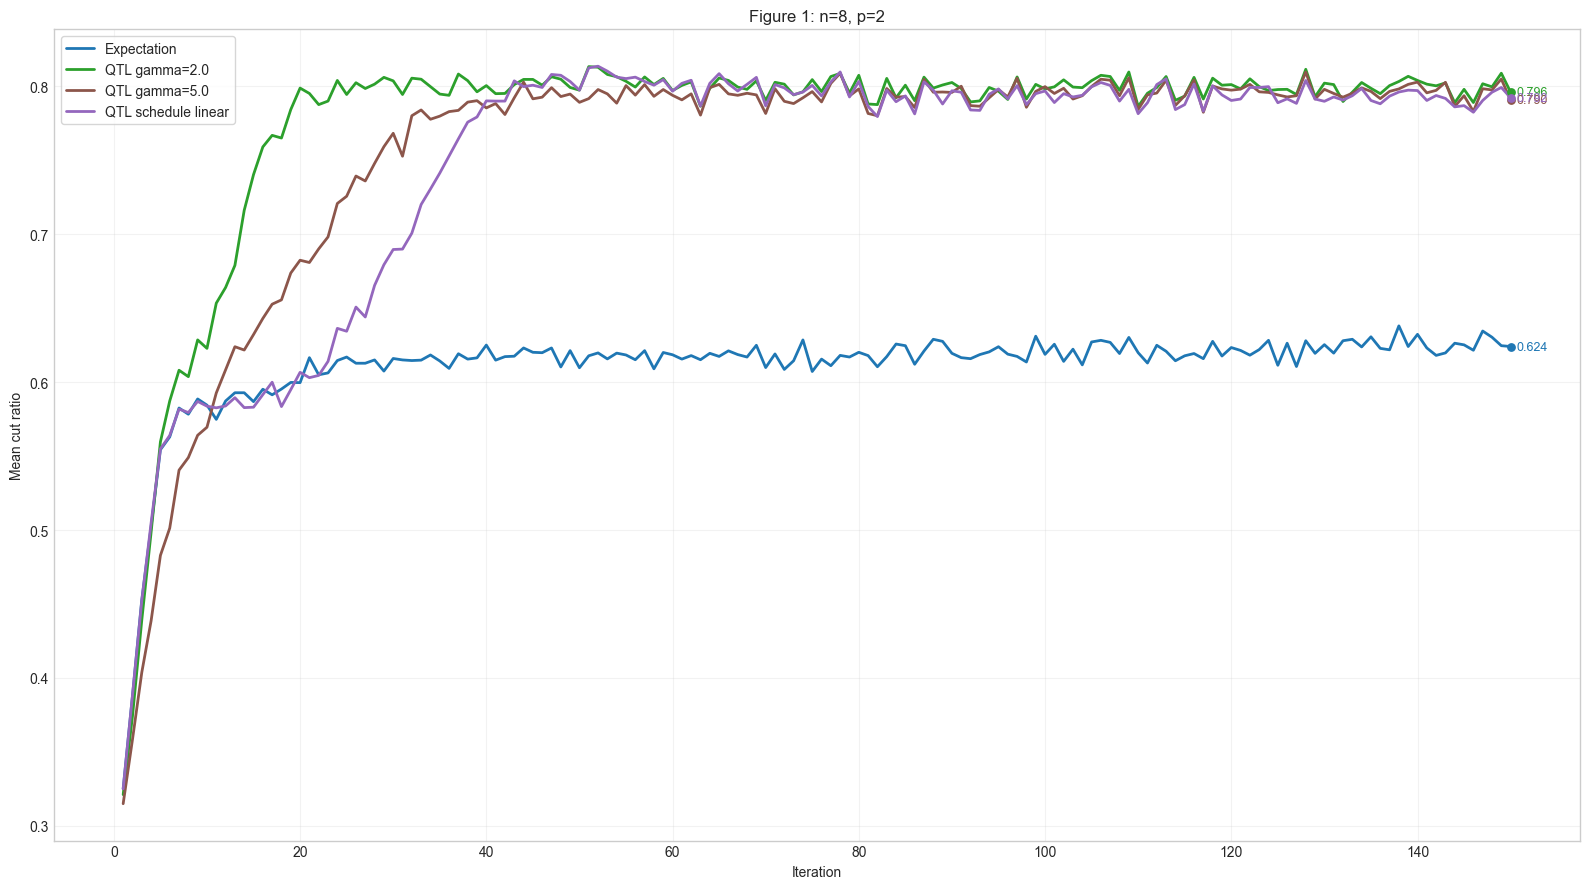

In [15]:
# fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(5 * len(RUN_CONFIG["depths"]), 4), sharey=True)
fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(16, 9), sharey=True)
if len(RUN_CONFIG["depths"]) == 1:
    axes = [axes]
    
for ax, p in zip(axes, RUN_CONFIG["depths"]):
    sub = fig1_df[fig1_df["p"] == p]
    plotted = []
    for name in CURVE_OBJECTIVES:
        agg = plot_mean_with_band(
            ax,
            sub[sub["objective"] == name],
            "iteration",
            "mean_ratio",
            name,
            OBJECTIVE_COLORS[name],
        )
        plotted.append((name, agg))
        ax.text(
            agg["iteration"].iloc[-1] + 0.6,
            agg["mean"].iloc[-1],
            f"{agg['mean'].iloc[-1]:.3f}",
            color=OBJECTIVE_COLORS[name],
            va="center",
            fontsize=9,
        )
    y_min = min(agg["mean"].min() for _, agg in plotted)
    y_max = max(agg["mean"].max() for _, agg in plotted)
    pad = max(0.002, 0.18 * (y_max - y_min + 1e-6))
    ax.set_title(f"Figure 1: n={RUN_CONFIG['curve_n']}, p={p}")
    # ax.set_xticks(list(range(1, len(sub[sub["objective"] == name]) + 1)))
    ax.locator_params(axis='x', integer=True)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean cut ratio")
    # ax.set_ylim(0.45, 1.00)
    ax.grid(alpha=0.25)

axes[0].legend(frameon=True)
plt.tight_layout()
plt.show()

## Gamma sweep for QTL on 4-qubit Erdos-Renyi Max-Cut

The cells below run a standalone numerical experiment: for each $\gamma \in [0, 20]$, we optimize a depth-$p=2$ QAOA ansatz with quantum tilted loss on 5 connected 4-node Erdos-Renyi graphs, then average the resulting mean cut ratio and plot it in a style inspired by the reference figure.


In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pennylane as qml
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import make_interp_spline
from scipy.optimize import minimize

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "font.family": "serif",
        "axes.titlesize": 24,
        "axes.labelsize": 22,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

N_QUBITS = 8
P_LAYERS = 2
GRAPH_COUNT = 5
ERDOS_RENYI_P = 0.45
GAMMA_VALUES = np.linspace(0.0, 50.0, 51)
MAXITER = 100
NUM_RESTARTS = 2


def connected_er_graph(n_qubits, edge_prob, seed):
    trial_seed = int(seed)
    while True:
        graph = nx.gnp_random_graph(n_qubits, edge_prob, seed=trial_seed)
        if graph.number_of_edges() > 0 and nx.is_connected(graph):
            return graph
        trial_seed += 1


def cut_spectrum(graph):
    n_qubits = graph.number_of_nodes()
    edges = sorted(graph.edges())
    basis = np.array(
        [list(map(int, f"{state:0{n_qubits}b}")) for state in range(2**n_qubits)],
        dtype=int,
    )
    cuts = np.zeros(len(basis), dtype=float)
    for u, v in edges:
        cuts += (basis[:, u] != basis[:, v]).astype(float)
    return edges, cuts, float(cuts.max())


def make_qaoa_probs_qnode(n_qubits, edges, depth):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def circuit(params):
        gammas = params[:depth]
        betas = params[depth:]
        for wire in range(n_qubits):
            qml.Hadamard(wires=wire)
        for layer in range(depth):
            for u, v in edges:
                qml.IsingZZ(2.0 * gammas[layer], wires=[u, v])
            for wire in range(n_qubits):
                qml.RX(2.0 * betas[layer], wires=wire)
        return qml.probs(wires=range(n_qubits))

    return circuit


def qtl_distribution_loss(probs, cuts, c_max, gamma_value):
    losses = c_max - cuts
    if abs(gamma_value) < 1e-12:
        return float(np.dot(probs, losses))
    loss_min = float(losses.min())
    shifted = losses - loss_min
    partition = np.sum(probs * np.exp(-gamma_value * shifted))
    return float(loss_min - np.log(partition) / gamma_value)


def mean_cut_ratio(probs, cuts, c_max):
    return float(np.dot(probs, cuts) / c_max)


def optimize_qaoa_for_gamma(circuit, cuts, c_max, gamma_value, init_params, rng):
    candidate_starts = [np.asarray(init_params, dtype=float)]
    for _ in range(NUM_RESTARTS - 1):
        candidate_starts.append(rng.uniform(0.0, np.pi, size=2 * P_LAYERS))

    best_run = None
    for start in candidate_starts:
        def objective(theta):
            wrapped = np.mod(theta, 2 * np.pi)
            probs = np.asarray(circuit(wrapped), dtype=float)
            return qtl_distribution_loss(probs, cuts, c_max, gamma_value)

        result = minimize(
            objective,
            x0=np.asarray(start, dtype=float),
            method="COBYLA",
            options={"maxiter": MAXITER, "rhobeg": 0.35, "tol": 1e-4},
        )
        params = np.mod(result.x, 2 * np.pi)
        probs = np.asarray(circuit(params), dtype=float)
        ratio = mean_cut_ratio(probs, cuts, c_max)
        loss = qtl_distribution_loss(probs, cuts, c_max, gamma_value)
        run = {
            "params": params,
            "mean_cut_ratio": ratio,
            "qtl_loss": loss,
        }
        if best_run is None or loss < best_run["qtl_loss"] - 1e-10:
            best_run = run
        elif abs(loss - best_run["qtl_loss"]) <= 1e-10 and ratio > best_run["mean_cut_ratio"]:
            best_run = run

    return best_run


records = []
for graph_seed in range(GRAPH_COUNT):
    graph = connected_er_graph(N_QUBITS, ERDOS_RENYI_P, seed=graph_seed)
    edges, cuts, c_max = cut_spectrum(graph)
    circuit = make_qaoa_probs_qnode(N_QUBITS, edges, P_LAYERS)
    graph_rng = np.random.default_rng(2026 + graph_seed)
    warm_start = graph_rng.uniform(0.0, np.pi, size=2 * P_LAYERS)

    for gamma_value in GAMMA_VALUES:
        best_run = optimize_qaoa_for_gamma(circuit, cuts, c_max, gamma_value, warm_start, graph_rng)
        warm_start = best_run["params"]
        records.append(
            {
                "graph_seed": graph_seed,
                "gamma": float(gamma_value),
                "mean_cut_ratio": best_run["mean_cut_ratio"],
                "qtl_loss": best_run["qtl_loss"],
                "edge_count": len(edges),
                "max_cut": c_max,
            }
        )

gamma_sweep_df = pd.DataFrame(records)
gamma_summary_df = (
    gamma_sweep_df.groupby("gamma")
    .agg(
        mean_cut_ratio=("mean_cut_ratio", "mean"),
        std_cut_ratio=("mean_cut_ratio", "std"),
    )
    .reset_index()
)
gamma_summary_df["std_cut_ratio"] = gamma_summary_df["std_cut_ratio"].fillna(0.0)

best_idx = gamma_summary_df["mean_cut_ratio"].idxmax()
best_gamma = float(gamma_summary_df.loc[best_idx, "gamma"])
best_ratio = float(gamma_summary_df.loc[best_idx, "mean_cut_ratio"])

x_dense = np.linspace(float(GAMMA_VALUES.min()), float(GAMMA_VALUES.max()), 400)
spline_degree = min(3, len(gamma_summary_df) - 1)
if spline_degree >= 1:
    y_dense = make_interp_spline(
        gamma_summary_df["gamma"],
        gamma_summary_df["mean_cut_ratio"],
        k=spline_degree,
    )(x_dense)
else:
    y_dense = np.full_like(x_dense, gamma_summary_df["mean_cut_ratio"].iloc[0], dtype=float)

y_min = max(0.55, float(gamma_summary_df["mean_cut_ratio"].min()) - 0.05)
y_max = min(1.01, float(gamma_summary_df["mean_cut_ratio"].max()) + 0.03)
y_dense = np.clip(y_dense, y_min, y_max)

best_region_half_width = 1.0
y_min = max(0.84, y_min)
y_max = min(0.96, y_max)



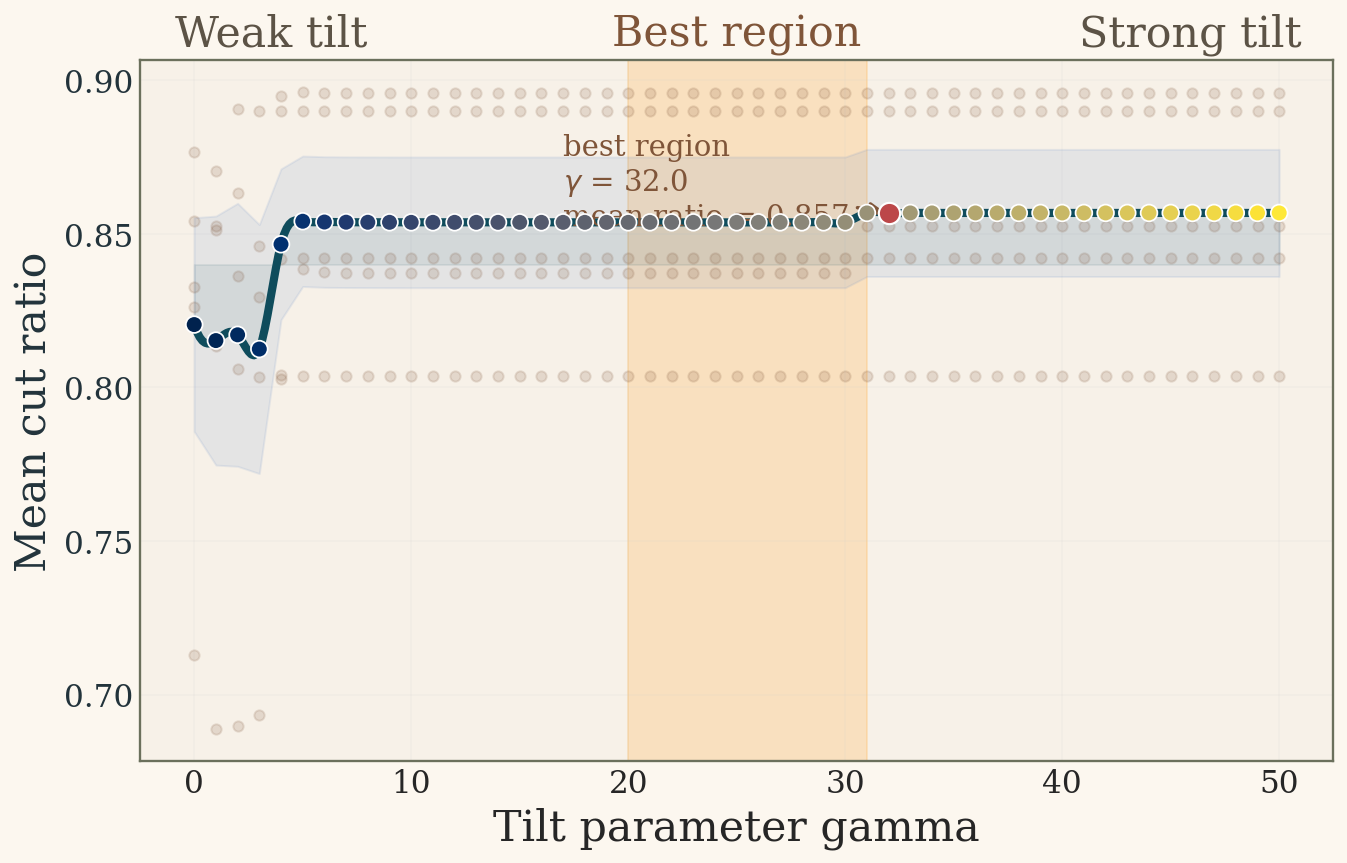

Saved /Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_mean_cut_ratio.png
Saved /Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_mean_cut_ratio.pdf


,gamma,mean_cut_ratio,std_cut_ratio
0,0.0,0.8204,0.0633
1,1.0,0.8152,0.0737
2,2.0,0.8171,0.0778
3,3.0,0.8125,0.0737
4,4.0,0.8466,0.0446
5,5.0,0.8541,0.0386
6,6.0,0.8538,0.0386
7,7.0,0.8538,0.0387
8,8.0,0.8537,0.0387
9,9.0,0.8537,0.0387


In [25]:

fig, ax = plt.subplots(figsize=(11.0, 6.5))
fig.patch.set_facecolor("#fcf7ef")
ax.set_facecolor("#f7f1e8")
ax.axvspan(
    max(0.0, best_gamma - best_region_half_width),
    min(20.0, best_gamma + best_region_half_width),
    color="#ffbf69",
    alpha=0.32,
    zorder=0,
)
ax.fill_between(
    gamma_summary_df["gamma"],
    gamma_summary_df["mean_cut_ratio"] - 0.55 * gamma_summary_df["std_cut_ratio"],
    gamma_summary_df["mean_cut_ratio"] + 0.55 * gamma_summary_df["std_cut_ratio"],
    color="#5f88c9",
    alpha=0.12,
    zorder=1,
)
ax.fill_between(x_dense, y_dense, y_min, color="#0f4c5c", alpha=0.08, zorder=1)
ax.scatter(
    gamma_sweep_df["gamma"],
    gamma_sweep_df["mean_cut_ratio"],
    color="#7f5539",
    s=28,
    alpha=0.16,
    zorder=2,
)
ax.plot(x_dense, y_dense, color="#0f4c5c", linewidth=4.2, zorder=3)
ax.scatter(
    gamma_summary_df["gamma"],
    gamma_summary_df["mean_cut_ratio"],
    c=gamma_summary_df["gamma"],
    cmap="cividis",
    s=74,
    edgecolor="white",
    linewidth=0.9,
    zorder=4,
)
ax.scatter([best_gamma], [best_ratio], color="#bc4749", s=120, edgecolor="white", linewidth=1.1, zorder=5)
ax.annotate(
    f"best region\n$\\gamma$ = {best_gamma:.1f}\nmean ratio = {best_ratio:.3f}",
    xy=(best_gamma, best_ratio),
    xytext=(min(17.0, best_gamma + 2.8), min(y_max - 0.01, best_ratio + 0.010)),
    fontsize=15,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.8},
)

ax.text(0.11, 1.02, "Weak tilt", transform=ax.transAxes, fontsize=22, ha="center", color="#5c5346")
ax.text(0.50, 1.02, "Best region", transform=ax.transAxes, fontsize=22, ha="center", color="#7f5539")
ax.text(0.88, 1.02, "Strong tilt", transform=ax.transAxes, fontsize=22, ha="center", color="#5c5346")

# ax.set_title("QTL-QAOA gamma sweep", pad=18, color="#22333b")
# ax.text(
#     0.02,
#     0.94,
#     "4-qubit connected Erdos-Renyi graphs, p=2, averaged over 5 graph instances",
#     transform=ax.transAxes,
#     fontsize=15,
#     color="#555555",
# )
ax.set_xlabel("Tilt parameter gamma")
ax.set_ylabel("Mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
# ax.set_xlim(0.0, 20.0)
# ax.set_ylim(y_min, y_max)
ax.grid(alpha=0.12)
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_mean_cut_ratio.png"
# output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_mean_cut_ratio.pdf"
fig.savefig(output_png, bbox_inches="tight", dpi=240)
fig.savefig(output_pdf, bbox_inches="tight")
plt.show()

print(f"Saved {output_png}")
print(f"Saved {output_pdf}")
display(gamma_summary_df.round(4))